In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import networkx as nx
import random
import heapq
import collections
from collections import deque
from copy import deepcopy, copy

### All the simulation uses hours and kilometers

In [2]:
ARRIVAL_RATE = np.array([314.2, 162.4, 138.6, 148.8, 273.2, 1118.8, 2773.8, 4036.2, 4237.4, 3277.0, 2843.0, 2876.4, 3143.0, 3277.8, 3546.2, 4335.0, 4945.4, 4525.8, 2847.8, 1828.0, 1378.4, 1271.2, 1171.2, 767.6])
INCIDENT_RATE = np.array([0.1935483870967742, 0.25806451612903225, 0.2903225806451613, 0.1935483870967742, 0.06451612903225806, 0.967741935483871, 32.16129032258065, 131.03225806451613, 157.2258064516129, 48.32258064516129, 8.451612903225806, 6.258064516129032, 8.161290322580646, 10.290322580645162, 19.0, 65.7741935483871, 157.41935483870967, 163.3548387096774, 36.54838709677419, 3.7096774193548385, 1.2258064516129032, 0.8709677419354839, 0.5806451612903226, 0.41935483870967744])
INCIDENT_DURATION_PARAMS = (1.2294425495153518, 0.09878316410683122, 5.082687545787541)

CITY_A = '45098337'
CITY_B = '42995944'

incident_duration_dist = stats.lognorm(*INCIDENT_DURATION_PARAMS)

MEAN_ACCIDENT_DURATION = incident_duration_dist.expect()/60

In [3]:
#Sampling arrival times of cars to network
def lambdat(lambda_t, t : np.array):
    lambdat = []
    for time in t:
        lambdat.append(lambda_t[int(np.floor(time))])
    return lambdat

def arrival_times(lam): #Taken from lecture notes
    max_T = 24
    arrival_times = collections.deque()
    exp_dist = stats.expon(scale = 1/lam)
    t = exp_dist.rvs()
    while t < max_T:
        arrival_times.append(t)
        t += exp_dist.rvs()
    
    return np.asarray(arrival_times)

In [4]:
#Computing cofidence interval
def confidence_interval(mean, var, Nruns):
    zalpha2 = 1.96
    half_width = zalpha2 * np.sqrt(var)/np.sqrt(Nruns)
    ci = (mean - half_width, mean + half_width)
    return ci

def mean_var(array):
    return np.mean(array), np.var(array)

#More data analysis
def compute_fraction_state(data, switch):
    #switch: 0 for cars stuck in traffic
    #        1 for number of accidents in network
    nruns = len(data)
    list_dics = []
    for n in range(nruns):
        total_time = 0.0
        time_in_state = {}
        if switch == 0:
            counts = np.cumsum(data[n].LIST_AMOUNT_CARS_TRAFFIC_CHANGE)    
        elif switch == 1:
            counts = np.cumsum(data[n].LIST_AMOUNT_INCIDENTS_CHANGE)
        times = data[n].TIME_ARRAY
        for i in range(len(times) - 1):
            k = counts[i]
            dt = times[i + 1] - times[i]
            time_in_state[k] = time_in_state.get(k, 0.0) + dt
            total_time += dt

        # Convert to fraction
        fraction_in_state = {k: time / total_time for k, time in time_in_state.items()}
        list_dics.append(fraction_in_state)
    return list_dics

def dicts_to_array(dict_list):
    # Find all keys that appear in any dictionary
    all_keys = sorted(set().union(*dict_list))
    
    # Create an array with shape (n_samples, n_keys)
    data = np.array([[d.get(k, 0.0) for k in all_keys] for d in dict_list])
    return np.array(all_keys), data

def mean_delayed_per_hour(data):
    list_dics = []
    for n in range(len(data)):
        times = data[n].TIME_ARRAY
        delayed = np.cumsum(data[n].LIST_AMOUNT_CARS_TRAFFIC_CHANGE)
        hour_buckets = {n:[] for n in range(0,24)}

        for t, d in zip(times, delayed):
            hour = np.floor(t)%24
            hour_buckets[hour].append(d)

        mean_per_hour = {hour: np.mean(values) for hour, values in hour_buckets.items()}
        list_dics.append(mean_per_hour)
    return list_dics

In [5]:
class FES:
    def __init__(self):
        self.events = []

    def add(self, event):
        heapq.heappush(self.events, event)
    
    def next(self):
        return heapq.heappop(self.events)
    
    def isEmpty(self):
        return len(self.events) == 0
    
    def __repr__(self):
        string = ''
        sorted_events = sorted(self.events)
        for event in sorted_events:
            string += f'{event}\n'
        return string

In [6]:
class Queue:
    def __init__(self, road):
        self.road = road
        self.cars = []

    def add(self, car, time):
        heapq.heappush(self.cars, car)
        car.enter_queue(time)

    def add_list(self, list, time):
        for car in list:
            heapq.heappush(self.cars, car)
            car.enter_queue(time)   

    def next(self):
        return heapq.heappop(self.cars)
    
    def first(self):
        return heapq.nsmallest(1, self.cars)
    
    def isEmpty(self):
        return len(self.cars) == 0
    
    def __repr__(self):
        string = ''
        sorted_cars = sorted(self.cars)
        for car in sorted_cars:
            string += f'{car}\n'
        return string

In [7]:
class Event:
    TYPE = ['New car', 'Car departure', 'Accident', 'Accident end', 'left queue']
    def __init__(self, typ:int, time, car = None, road = None, duration=None, location=None):
        #types:
            #0 : Arrival of car to the network
            #1 : Car leaves current road and goes on to the next
            #2 : Accident in road
            #3 : End of accident
            #4 : Departure of car from queue of accident
        self.type = typ
        self.time = time
        self.road = road
        self.location = location
        self.duration = duration
        self.cancelled = False

        if typ == 0:
            car = Car(time_entrance = time)
    
        self.car = car
        
    def __str__(self):
        if self.type == 0:
            return f'{self.TYPE[self.type]} from {self.car.origin} to {self.car.destination} at {self.time}'
        if self.type == 1:
            return f'{self.TYPE[self.type]} of {self.car} at {self.time}h'
        if self.type == 2:
            return f'{self.TYPE[self.type]} at {self.road} at {self.time}h'
        if self.type == 3:
            return f'{self.TYPE[self.type]} at {self.road} at {self.time}h'
        if self.type == 4:
            return f'{self.car} {self.TYPE[self.type]} at {self.road} at {self.time}h'

    def __lt__(self, other):
        return self.time < other.time
    
    def new_time(self, new_time):
        self.time = new_time

In [8]:
class Car:
    VELOCITIES = [100, 80]
    VELOCITIES_P = [0.9, 0.1]
    NAVIGATION_P = 0.5
    def __init__(self, time_entrance, origin = None, destination = None):
        #Origin and destination
        origin, destination = np.random.choice(JUNCTIONS, 2, replace = False)
        
        self.origin = origin
        self.destination = destination

        #path to follow
        self.path = nx.shortest_path(Graph, self.origin, self.destination, weight = 'length')

        #Velocity
        self.velocity = np.random.choice(self.VELOCITIES, p=self.VELOCITIES_P)

        #Variable to keep track how far into the path we are (to simplify scheduling events)
        #Int between 0 and len(path) - 1 that indicates in which edge we are, starting at 0
        #Essentially, how many edges has it travelled so far
        self.progress = 0
        
        #Give it nav with 10% chance
        self.has_nav = np.random.choice([True, False], p=[self.NAVIGATION_P, 1 - self.NAVIGATION_P])
        self.changed_route = []

        #Time entrance
        self.time = time_entrance
        self.time_entrance = time_entrance

        self.time_enter_q = 0

        #keeping track of amount of accidents encountered
        self.accidents = 0
        self.time_delayed = 0
        self.next_event = None



    def __str__(self):
        return f'Vehicle travelling from {self.origin} to {self.destination} at {self.velocity} km/h, atm at {self.path[self.progress-1],self.path[self.progress]}, time {self.time}h'
    

    def custom_weight(self,u,v,data):
        """
        :param u: std for accepting function as weight, node 1
        :param v:  std for accepting function as weight, node 2
        :param data: std for accepting function as weight, edge
        :return: time_to_travel + delay
        """
        length = data['length']
        time_to_travel = (length / (self.velocity /3.6)) / 3600 #Mean of normal dist
        if Graph.edges[(u,v)]['accident']:   
            delay = MEAN_ACCIDENT_DURATION
        else:
            delay = 0
        return time_to_travel + delay
    
    def calc_time_to_travel(self,length):
        """
        :param length: edge length
        :return: returns time to traverse length based on normal speed
        """
        mean = length / (self.velocity /3.6) #seconds
        std = mean / 20
        time_to_travel = np.random.normal(loc = mean, scale = std) / 3600 #back to hours
        return max(0,time_to_travel)

    def schedule_event_exit(self):
        #Remove car from list of cars in previous edge
        if self.progress > 0:
            edge = (self.path[self.progress - 1], self.path[self.progress])
            DIC_EDGES[edge].remove(self)


        if self.progress < len(self.path) - 1:
            # Get the current and next node on the original path
            current_node = self.path[self.progress]
            next_node = self.path[self.progress + 1]
            edge = Graph.edges[(current_node, next_node)]

            # Check for accident on the current edge and if nav is enabled
            # No need to check for accident, just check if navigation (there may be accidents later that makes us recompute)
            if self.has_nav:
                # print("Updating path")
                new_path = nx.shortest_path(Graph, current_node, self.destination, weight=self.custom_weight)

                if new_path != self.path[self.progress:]:
                    # print("Found a quicker route")
                    # print(f"Prev path = {[Graph.nodes[node]['name'] for node in self.path]}")
                    # print(f"New path = {[Graph.nodes[node]['name'] for node in new_path]}")

                    #I commented this out bc append is not efficient
                    # self.changed_route.append((self.path, new_path))

                    # Preserve the already traversed portion
                    prefix = self.path[:self.progress]

                    updated_path = prefix + new_path
                    # print(updated_path)
                    # self.path = updated_path
                    # print(f"Updated path: {[Graph.nodes[node]['name'] for node in self.path]}")

                    # Update next_node based on the new path
                    next_node = self.path[self.progress + 1]
                    edge = Graph.edges[(current_node, next_node)]
                    length = edge['length']
                    # Sample travel time along the new edge (including accident delay)
                    
                    #I think no need to add accident duration bc i account for this in my code alr and a accident can happen before scheduling this
                    # time_to_travel = self.calc_time_to_travel(length) + edge['accident_duration']
                    time_to_travel = self.calc_time_to_travel(length)
                else:
                    # No change in path (fallback scenario)
                    length = edge['length']
                    time_to_travel = self.calc_time_to_travel(length)
            else:
                # Normal travel (no accident on the edge)
                length = edge['length']
                time_to_travel = self.calc_time_to_travel(length)

            new_time = self.time + time_to_travel
            # Schedule next event and update car's progress and time
            self.next_event = Event(1, new_time, car=self)
            # , road=(current_node, next_node))
            self.increase_progress()
            self.increase_time(new_time)

            #Add car to list of cars in the new edge
            # edge = (self.path[self.progress - 1], self.path[self.progress])
            DIC_EDGES[(current_node, next_node)].append(self)

            return self.next_event
    
    def increase_progress(self):
        self.progress += 1

    def increase_time(self, new_time):
        self.time = new_time

    def __lt__(self, other):
        return self.time < other.time
    
    def enter_queue(self, time):
        #store time at which the car entered the queue
        self.time_enter_q = time
        self.next_event.cancelled = True
        self.accidents += 1

    def exit_queue(self, time_exit):
        #Update time of car when it left the queue
        time_queue = time_exit - self.time_enter_q
        self.time_delayed += time_queue
        self.time += time_queue
        # print(self.progress)
        new_event_exit = copy(self.next_event)
        # print(self.progress)
        new_event_exit.new_time(self.time)
        new_event_exit.cancelled = False
        # self.next_event.cancelled = True
        self.next_event = new_event_exit
        return new_event_exit
    
    def compute_path_length(self):
        length = 0
        if len(self.path) > 0:
            for n in range(len(self.path) - 1):
                edge = (self.path[n], self.path[n+1])
                length += Graph.edges[edge]['length']

            return length * 10**(-3) #back to km
        else:
            return 0.0

In [9]:
class TowTruck:
    def __init__(self, origin, name=f"Truck {random.randint(0,100)}"):
        self.origin = origin
        self.isHome = True
        self.velocity = 80
        self.progress = 0
        self.time = 0
        self.going_home = False
        self.name = name
        self.next_event = None
    def __str__(self):
        at = self.path[self.progress]
        return f"Tow Truck travelling from {Graph.nodes[self.origin]['name']} to {Graph.edges[self.destination_road]} at {self.velocity} km/h, atm at {Graph.nodes[at]['name']}"

    def calc_time_to_travel(self,length):
        """
        :param length: edge length
        :return: returns time to traverse length based on normal speed
        """
        mean = length / (self.velocity /3.6) #seconds
        std = mean / 20
        time_to_travel = np.random.normal(loc = mean, scale = std) / 3600 #back to hours
        return time_to_travel

    def new_destination(self, destination_road, destination, current_time, distance_from_junction):
        if self.isHome:
            #Lets make destination = first item in destination road
            if self.origin == destination:
                self.destination = destination_road[1]
            else:
                 self.destination = destination
            self.destination_road = destination_road
            self.add_d = distance_from_junction
            self.path = nx.shortest_path(Graph, self.origin, self.destination, weight = 'length')
            self.isHome = False
            self.going_home = False
            self.time = current_time
            new_event = self.schedule_event_exit()
            
            return new_event
        # else:
            # print("Not able to set new destination, vehicle still on the road.")

    def schedule_event_exit(self):
        #Car is travelling and did not reach destination yet

        if  self.progress < len(self.path) - 1:
            # Can go on emergency lane so doesn't care for traffic jam
            current_node = self.path[self.progress]
            next_node = self.path[self.progress + 1]
            # print(f"{self.name} Now going from {Graph.nodes[current_node]['name']} to {Graph.nodes[next_node]['name']} at time {self.time}\n")

            length = Graph.edges[(current_node,next_node)]['length']
            time_to_travel = self.calc_time_to_travel(length)

            new_time = self.time + time_to_travel
            # print(f"{self.name} reaching {Graph.nodes[next_node]['name']} at time {new_time}\n")
            #Store event and increase progress
            self.next_event = Event(1 , new_time, car=self)
            self.increase_progress()
            self.increase_time(new_time)
            
            # if self.going_home:
                # print('On its way home')

            return self.next_event

        # Car reached destination, and is not going home
        elif (not(self.going_home)) and (self.progress == len(self.path) - 1):
            if self.origin == self.destination:
                # print("TRIGGERED GORINCHEM ISSUE")
                self.progress =0
                # reached destination, Drive additional length to incident:
                self.time +=  self.calc_time_to_travel(self.add_d)
                # print(f"Increased time {self.name} time to {self.time}")
                solving_event = Event(3, self.time, road = self.destination_road)
                # print(f" {self.name} Solved event time {self.time}")
                # Calculate how long it takes to get to the other side of the road, i.e. next junction
                tot_road_length = nx.path_weight(Graph, self.destination_road,weight='length')
                # 'Drive' to other side
                self.time += self.calc_time_to_travel(tot_road_length-self.add_d)
                # print(f" Arrived at opposite side of the road {self.time}")
                # Calculate new path from other side of the road
                self.path = [self.destination_road[1],self.destination_road[0]]
                # print(f" Path to get back:{Graph.nodes[self.destination_road[1]]['name']} -> {Graph.nodes[self.destination_road[0]]['name']} {self.time}")
                length = Graph.edges[tuple(self.path)]['length']
                time_to_travel = self.calc_time_to_travel(length)
                new_time = self.time + time_to_travel
                # print(f" Arrived back at origin base {new_time}")
                self.progress = len(self.path)-1
                self.increase_time(new_time)
                # print(f" updated time to {self.time}")
                self.isHome = True
                self.going_home = False
                # print(f"Now sending event back to event handler")
                return ['Truck back', solving_event]


            # reached destination, Drive additional length to incident:
            self.time +=  self.calc_time_to_travel(self.add_d)
            solving_event = Event(3, self.time, road = self.destination_road)
            # Calculate how long it takes to get to the other side of the road, i.e. next junction
            tot_road_length = nx.path_weight(Graph, self.destination_road,weight='length')
            # 'Drive' to other side
            self.time += self.calc_time_to_travel(tot_road_length-self.add_d)
            # Calculate new path from other side of the road

            self.path = nx.shortest_path(Graph, self.destination_road[1], self.origin, weight = 'length')

            # Reset progress
            # print(f"New path {[Graph.nodes[nodes]['name'] for nodes in self.path]}")
            self.progress = 0

            # edge = Graph.edges[(self.destination, self.path[1])]
            # print('Heading home')
            if len(self.path) > 1:
                # print("##### Flag 0 #####")
                length = Graph.edges[(self.destination_road[1], self.path[1])]['length']

                time_to_travel = self.calc_time_to_travel(length)
                new_time = self.time + time_to_travel

                self.increase_progress()
                self.increase_time(new_time)
                self.next_event = Event(1, new_time, car=self)
                self.going_home = True
                
                return [self.next_event, solving_event]
            else:
                #Never triggered, Alr at home
                # print("##### Flag 1 #####")
                self.isHome = True
                self.going_home = False
                return ['Truck back', solving_event]
        # Car is going home, and reached destination, thus reached home
        elif (self.going_home) and (self.progress == len(self.path) - 1):
            self.isHome = True
            self.going_home = False
            return 'Truck back'

    def increase_progress(self):
        self.progress += 1

    def increase_time(self, new_time):
        self.time = new_time



In [10]:
class IncidentSolvers:
    def __init__(self,K_trucks, origin ='2752332143'):
        self.origin = origin
        self.K_trucks = K_trucks
        self.trucks = []
        self.available = deque()
        self.unavailable = deque()
        for i in range(K_trucks):
            truck = TowTruck(origin=origin)
            truck.name = f"Truck {i}"

            self.trucks.append(truck)
            self.available.append(truck)

    def truck_returned(self, truck):
        if truck in self.unavailable:
            self.unavailable.remove(truck)

        self.available.append(truck)
        truck.progress = 0
        truck.isHome = True
        truck.going_home = False
        truck.path = None
        # print(f"Truck {truck.name} returned to base at time {truck.time}")
        # print("Trucks available after return:",len(self.available),'\n')


    def send_truck(self, destination_road, incident_duration, current_time,location):
        # print(f"trying to send a truck, \n \
        # amount trucks available: {len(self.available)} \n trucks available: {[truck.name for truck in self.available]}\n")
        if len(self.available) > 0:
            truck = self.available.pop()
            # Check if truck can reach in time
            destination = destination_road[0]
            path = nx.shortest_path(Graph, self.origin, destination, weight='length')
            length = nx.path_weight(Graph, path,weight='length')
            length_additional = location * nx.path_weight(Graph, destination_road,weight='length')
            time_to_travel = truck.calc_time_to_travel(length + length_additional)


            if time_to_travel> incident_duration:
                # print("Takes too long to reach incident location\n")
                self.available.append(truck)
                return
            else:
                # Send the truck to the incident.
                # print(f"sending truck {truck.name} to {Graph.nodes[destination]['name']} at time {current_time}\n")
                # print(f"location {location*100}% from {Graph.nodes[destination_road[0]]['name']} to {Graph.nodes[destination_road[1]]['name']} ")
                # print(f"Incident at {length_additional} from {Graph.nodes[destination]['name']}, total_length = {nx.path_weight(Graph, destination_road,weight='length')}")
                # print(f"Reaching {Graph.nodes[destination]['name']} at {current_time+ truck.calc_time_to_travel(length)} ")
                reaching_time = current_time + time_to_travel
                # print(f"Reaching incident at {reaching_time} incident should be solved atmost {current_time + incident_duration}\n")
                event_truck = truck.new_destination(destination_road,destination, current_time, distance_from_junction=length_additional)
                self.unavailable.append(truck)
                return event_truck

        # else:
            # print('No trucks available sry')

In [11]:
# road = list(DIC_EDGES.keys())[0]
# accident = Event(2, 0.5, road=road, duration=0.1, location=0.4)
# end_accident = Event(3, 0.6, road =road)
# fes.add(accident)
# fes.add(end_accident)
# # # road = road[::-1]
# # # accident = Event(2, 0.5, road=road)
# # # end_accident = Event(3, 0.6, road =road)
# # # fes.add(accident)
# # # fes.add(end_accident)

In [ ]:
class SimulationData:

    def __init__(self):
        self.LIST_CARS = []
        self.LIST_TRUCKS = []
        self.LIST_VEHICLES = []
        self.LIST_CARS_AB = []

        self.LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        self.LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        self.TIME_ARRAY = []

In [20]:
class Simulation:

    def __init__(self, Nruns):
        self.nruns = Nruns
        self.data2 = [SimulationData() for _ in range(Nruns)]
        self.data3 = [SimulationData() for _ in range(Nruns)]
        self.data4 = [SimulationData() for _ in range(Nruns)]
        self.table_data2 = []
        self.table_data3 = []
        self.table_data4 = []
    
    def run_simulation3(self, iteration):
        data_storage = self.data3[iteration]
        #Using a thining approach to get arrival times
        max_lambda = np.max(ARRIVAL_RATE) + 1
        all_arrivals = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_arrivals))
        accept_filter = u_rvs * max_lambda < lambdat(ARRIVAL_RATE, all_arrivals)

        accepted_arrivals = all_arrivals[accept_filter]

        #Using a thining approach to get accident times
        max_lambda = np.max(INCIDENT_RATE) + 1
        all_accidents = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_accidents))
        accept_filter = u_rvs * max_lambda < lambdat(INCIDENT_RATE, all_accidents)

        accepted_accidents = all_accidents[accept_filter]

        global Graph
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        global JUNCTIONS
        JUNCTIONS = list(Graph.nodes)

        global DIC_EDGES
        DIC_EDGES = {}
        #Dictionary that keeps track on when the last accident ends in a road before another one can take place
        DIC_ACCIDENTS = {}
        for edge in Graph.edges:
            DIC_EDGES[edge] = []
            DIC_ACCIDENTS[edge] = 0
            #Associate departure from queue distribution to each edge based on number of lanes
            rate = 0.2/(60 * Graph.edges[edge]['lanes'])
            Graph.edges[edge]['DepDist'] = stats.expon(scale = rate)

            Graph.edges[edge]['accident'] = False
            Graph.edges[edge]['queue'] = False
            # Graph.edges[edge]['accident_duration'] = 0

        #Simulation (can be turned into an object later)
        # LIST_CARS = []
        # LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        # LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        # TIME_ARRAY = []
        fes = FES()
        for arrival in accepted_arrivals:
            #Two events associated with each arrival
            arrival_event = Event(0, arrival)
            fes.add(arrival_event)

        for accident in accepted_accidents:
            affected_road = list(Graph.edges)[np.random.choice(len(Graph.edges))]
            if DIC_ACCIDENTS[affected_road] < accident:
                location = stats.uniform.rvs()
                duration = incident_duration_dist.rvs()/60
                time_end = accident + duration
                accident_event = Event(2, accident, road=affected_road, duration=duration, location=location)
                end_accident = Event(3, time_end, road=affected_road)

                fes.add(accident_event)
                fes.add(end_accident)
                DIC_ACCIDENTS[affected_road] = time_end
        # heapq.heapify(fes.events)
        #Queue for accidents setup
        Queues = {}
        for edge in DIC_EDGES.keys():
            Queues[edge] = Queue(edge)
            
        t = 0 #current time
        step = 0
        while t < 24.0:
            event = fes.next()
            if not(event.cancelled):
                if t> event.time:
                    print('OH OH OH OH')
                    print(event)
                t = event.time
                data_storage.TIME_ARRAY.append(t)
                
                
                # print(t)
                #Car joins network
                if event.type == 0:
                    
                    car = event.car
                    
                    #Schedule next event and store it as attribute
                    car.next_event = car.schedule_event_exit()
                    car_travel_event = car.next_event
                    if car_travel_event.time <= t:
                        print('Problem 0')
                    fes.add(car_travel_event)

                    #Data storage
                    data_storage.LIST_VEHICLES.append(car)
                    if car.velocity == 80:
                        data_storage.LIST_TRUCKS.append(car)
                    elif car.velocity == 100:
                        data_storage.LIST_CARS.append(car)
                        
                        if car.origin == CITY_A and car.destination == CITY_B:
                            data_storage.LIST_CARS_AB.append(car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)

                #Car leaves road
                if event.type == 1:
                    
                    car = event.car
                    # print(car.progress)
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # print(car)
                    next_travel_event_car = car.schedule_event_exit()
                    if type(next_travel_event_car) == Event: #If the car has arrived to its destination it wont return an event object
                        if next_travel_event_car.time < t:
                            print('Problem 1')
                        fes.add(next_travel_event_car)
                        road = (car.path[car.progress -1], car.path[car.progress])
                        if Graph.edges[road]['queue'] or Graph.edges[road]['accident']:
                            Queues[road].add_list([car], event.time)
                            data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(1)
                        else:
                            data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    else:
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                            
                        
                    
                    # else:
                        # print(event.car)

                #Start accident
                if event.type == 2:
                    road = event.road
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(1)
                    #choose random cars affected:
                        #List comprehension is inefficient af here
                        # cars_not_in_queue = [car for car in DIC_EDGES[road] if car not in Queues[road].cars]
                    cars_not_in_queue = sorted(list(set(DIC_EDGES[road]) - set(Queues[road].cars)))
                    if len(cars_not_in_queue) != 0:
                        amount_cars_affected = int(np.floor(event.location * len(cars_not_in_queue)))
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(amount_cars_affected)
                        cars_affected = cars_not_in_queue[:amount_cars_affected]

                        # print(f'Time enter queue {event.time}')
                        Queues[road].add_list(cars_affected, event.time)
                        
                    Graph.edges[road]['accident'] = True

                    #Assuming end of accident event is already created, else create here
                    # print(f'{t}')

                #End accident
                if event.type == 3:
                    
                    road = event.road
                    #1 minute until first car leaves the queue 
                    if not(Queues[road].isEmpty()) and not(Graph.edges[road]['queue']):
                        # print(Queues[road])
                        # print(f'First event departure {Queues[road].isEmpty()}', road)
                        first_departure_event = Event(4, event.time, road=road)
                        # print(first_departure_event)
                        fes.add(first_departure_event)
                        if first_departure_event.time < t:
                            print('Problem 3')
                        Graph.edges[road]['queue'] = True
                    Graph.edges[road]['accident'] = False   
                    # print(t)
                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(-1)
                # 
                #Departure from queue
                if event.type == 4:
                    
                    # print(event)
                    road = event.road
                    time = event.time
                    #Remove car from queue
                    # print(len(Queues[road].cars), event.road)
                    car = Queues[road].next()
                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(-1)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                    # print(car.progress)
                    #Modify time to arrival of next node in path
                    # print(f'Time exit queue {event.time}')
                    # print(f'Previous event at {car.time}')
                    new_event_exit = car.exit_queue(time)
                    # print(f'New event at {new_event_exit.time}')
                    fes.add(new_event_exit)
                    # print(f'Equivalent cars {car1==car}')
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # heapq.heapify(fes.events)

                    if not(Queues[road].isEmpty()):
                        #Next departure event
                        next_event_time = time + Graph.edges[road]['DepDist'].rvs()
                        
                        next_event = Event(4, next_event_time, road=road)
                        if next_event.time < t:
                            print('Problem 4')
                        # print(next_event)
                        fes.add(next_event)
                    else:
                        Graph.edges[road]['queue'] = False

                # heapq.heapify(fes.events)
                # print(t)
                step += 1

    def run_simulation2(self, iteration):
        data_storage = self.data2[iteration]
        #Using a thining approach to get arrival times
        max_lambda = np.max(ARRIVAL_RATE) + 1
        all_arrivals = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_arrivals))
        accept_filter = u_rvs * max_lambda < lambdat(ARRIVAL_RATE, all_arrivals)

        accepted_arrivals = all_arrivals[accept_filter]

        global Graph
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        global JUNCTIONS
        JUNCTIONS = list(Graph.nodes)

        global DIC_EDGES
        DIC_EDGES = {}

        for edge in Graph.edges:
            DIC_EDGES[edge] = []
            Graph.edges[edge]['accident'] = False
            Graph.edges[edge]['queue'] = False
            # Graph.edges[edge]['accident_duration'] = 0

        #Simulation (can be turned into an object later)
        # LIST_CARS = []
        # LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        # LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        # TIME_ARRAY = []
        fes = FES()
        for arrival in accepted_arrivals:
            #Two events associated with each arrival
            arrival_event = Event(0, arrival)
            fes.add(arrival_event)
        # heapq.heapify(fes.events)
            
        t = 0 #current time
        step = 0
        while t < 24.0:
            event = fes.next()
            if not(event.cancelled):
                if t> event.time:
                    print('OH OH OH OH')
                    print(event)
                t = event.time
                data_storage.TIME_ARRAY.append(t)
                
                
                # print(t)
                #Car joins network
                if event.type == 0:
                    
                    car = event.car
                    
                    #Schedule next event and store it as attribute
                    car.next_event = car.schedule_event_exit()
                    car_travel_event = car.next_event
                    if car_travel_event.time <= t:
                        print('Problem 0')
                    fes.add(car_travel_event)

                    #Data storage
                    data_storage.LIST_VEHICLES.append(car)
                    if car.velocity == 80:
                        data_storage.LIST_TRUCKS.append(car)
                    elif car.velocity == 100:
                        data_storage.LIST_CARS.append(car)
                        
                        if car.origin == CITY_A and car.destination == CITY_B:
                            data_storage.LIST_CARS_AB.append(car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)

                #Car leaves road
                if event.type == 1:
                    
                    car = event.car
                    # print(car.progress)
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # print(car)
                    next_travel_event_car = car.schedule_event_exit()
                    if type(next_travel_event_car) == Event: #If the car has arrived to its destination it wont return an event object
                        if next_travel_event_car.time < t:
                            print('Problem 1')
                        fes.add(next_travel_event_car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                            
                        
                # heapq.heapify(fes.events)
                # print(t)
                step += 1

    def run_simulation4(self, iteration, amount_trucks):

        data_storage = self.data4[iteration]

        #Using a thining approach to get arrival times
        max_lambda = np.max(ARRIVAL_RATE) + 1
        all_arrivals = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_arrivals))
        accept_filter = u_rvs * max_lambda < lambdat(ARRIVAL_RATE, all_arrivals)

        accepted_arrivals = all_arrivals[accept_filter]

        #Using a thining approach to get accident times
        max_lambda = np.max(INCIDENT_RATE) + 1
        all_accidents = arrival_times(max_lambda)

        uniform_dist = stats.uniform(0,1)
        u_rvs = uniform_dist.rvs(len(all_accidents))
        accept_filter = u_rvs * max_lambda < lambdat(INCIDENT_RATE, all_accidents)

        accepted_accidents = all_accidents[accept_filter]

        global Graph
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        global JUNCTIONS
        JUNCTIONS = list(Graph.nodes)

        global DIC_EDGES
        DIC_EDGES = {}
        #Dictionary that keeps track on when the last accident ends in a road before another one can take place
        DIC_ACCIDENTS = {}
        for edge in Graph.edges:
            DIC_EDGES[edge] = []
            DIC_ACCIDENTS[edge] = 0
            #Associate departure from queue distribution to each edge based on number of lanes
            rate = 0.2/(60 * Graph.edges[edge]['lanes'])
            Graph.edges[edge]['DepDist'] = stats.expon(scale = rate)

            Graph.edges[edge]['accident'] = False
            Graph.edges[edge]['queue'] = False
            # Graph.edges[edge]['accident_duration'] = 0

        #Simulation (can be turned into an object later)
        # LIST_CARS = []
        # LIST_AMOUNT_CARS_TRAFFIC_CHANGE = [0]
        # LIST_AMOUNT_INCIDENTS_CHANGE = [0]
        # TIME_ARRAY = []
        fes = FES()
        for arrival in accepted_arrivals:
            #Two events associated with each arrival
            arrival_event = Event(0, arrival)
            fes.add(arrival_event)

        for accident in accepted_accidents:
            affected_road = list(Graph.edges)[np.random.choice(len(Graph.edges))]
            if DIC_ACCIDENTS[affected_road] < accident:
                location = stats.uniform.rvs()
                duration = incident_duration_dist.rvs()/60
                time_end = accident + duration
                accident_event = Event(2, accident, road=affected_road, duration=duration, location=location)
                end_accident = Event(3, time_end, road=affected_road)

                fes.add(accident_event)
                fes.add(end_accident)
                DIC_ACCIDENTS[affected_road] = time_end
        # heapq.heapify(fes.events)
        #Queue for accidents setup
        Queues = {}
        for edge in DIC_EDGES.keys():
            Queues[edge] = Queue(edge)

        incident_solvers = IncidentSolvers(amount_trucks)

        t = 0 #current time
        while t < 24.0:
            event = fes.next()
            if not(event.cancelled):
                if t> event.time:
                    print('OH OH OH OH')
                    print(event)
                t = event.time
                data_storage.TIME_ARRAY.append(t)
                # print(t)
                #Car joins network
                if event.type == 0:
                    
                    car = event.car
                    
                    #Schedule next event and store it as attribute
                    car.next_event = car.schedule_event_exit()
                    car_travel_event = car.next_event
                    if car_travel_event.time <= t:
                        print('Problem 0')
                    fes.add(car_travel_event)

                    #Data storage
                    data_storage.LIST_VEHICLES.append(car)
                    if car.velocity == 80:
                        data_storage.LIST_TRUCKS.append(car)
                    elif car.velocity == 100:
                        data_storage.LIST_CARS.append(car)
                        
                        if car.origin == CITY_A and car.destination == CITY_B:
                            data_storage.LIST_CARS_AB.append(car)

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)

                #Car leaves road
                if event.type == 1:
                    car = event.car
                    # print(car.progress)
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # print(car)
                    next_travel_event_car = car.schedule_event_exit()
                    if type(next_travel_event_car) == Event: #If the car has arrived to its destination it wont return an event object
                        if next_travel_event_car.time < t:
                            print('Problem 1')
                        fes.add(next_travel_event_car)
                    # else:
                        if type(car) == Car: #Twon trucks cant join the traffic queue
                            road = (car.path[car.progress -1], car.path[car.progress])
                            if Graph.edges[road]['queue'] or Graph.edges[road]['accident']:
                                Queues[road].add_list([car], event.time)
                                data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(1)
                            else:
                                data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)

                        else:
                            data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    else:
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                        # print(event.car)

                    #when a tow truck arrives to the accident it wants to solve, it will return two events
                    if type(next_travel_event_car) == list:
                        #Event for fixing the accident
                        fes.add(next_travel_event_car[1])
                        # print(f'Tow truck solved accident {t} truck time:{event.car.time}')

                        # print(next_travel_event_car)
                        #Event for heading back
                        if type(next_travel_event_car[0]) == Event:
                            fes.add(next_travel_event_car[0])
                        #it may alr be at home
                        elif next_travel_event_car[0] == 'Truck back':
                            incident_solvers.truck_returned(event.car)
                            # print(f'Tow truck back {t} truck time:{event.car.time}')

                    if next_travel_event_car == 'Truck back':
                        incident_solvers.truck_returned(event.car)
                        # print(f'Tow truck back {t} truck time:{event.car.time}')
                    # else:
                        # print(event.car)

                #Start accident
                if event.type == 2:
                    road = event.road
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(1)
                    #choose random cars affected:
                        #List comprehension is inefficient af here
                        # cars_not_in_queue = [car for car in DIC_EDGES[road] if car not in Queues[road].cars]
                    cars_not_in_queue = sorted(list(set(DIC_EDGES[road]) - set(Queues[road].cars)))
                    if len(cars_not_in_queue) != 0:
                        amount_cars_affected = int(np.floor(event.location * len(cars_not_in_queue)))
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(amount_cars_affected)
                        cars_affected = cars_not_in_queue[:amount_cars_affected]

                        # print(f'Time enter queue {event.time}')
                        Queues[road].add_list(cars_affected, event.time)
                    else:
                        data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    Graph.edges[road]['accident'] = True
                    #Assuming end of accident event is already created, else create here
                    # print(f'{t}')
                    # print("This road:",road)

                    # Location on the road
                    # Trying to keep it simple for debug purpose
                    # Loc * Length / velocity will be the additional time it takes

                    first_event_truck = incident_solvers.send_truck(road, event.duration, event.time, location = event.location)
                    # print(f'1330 {first_event_truck}, {type(first_event_truck)}')
                    #If no trucks are available first_event_truck will be empty
                    if type(first_event_truck) == Event:
                        fes.add(first_event_truck)
                        # print(f'Tow truck on its way {t}')
                    elif type(first_event_truck) == list:
                        fes.add(first_event_truck[1])
                        # print(f'Tow truck on its way {t}')
                    # else:
                        # print(f'Tow trucks all busy  {t}')

                #End accident
                if event.type == 3:
                    road = event.road
                    #A tow truck may have ended he accident before so there could be two events for ending it, hence only do it if there is still an accident
                    if Graph.edges[road]['accident']:
                        #1 minute until first car leaves the queue 
                        if not(Queues[road].isEmpty()) and not(Graph.edges[road]['queue']):
                            # print(f'First event departure {Queues[road].isEmpty()}', road)
                            first_departure_event = Event(4, event.time + 1/60, road=road)
                            # print(first_departure_event)
                            fes.add(first_departure_event)
                            Graph.edges[road]['queue'] = True
                        Graph.edges[road]['accident'] = False   

                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(0)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(-1)
                    # print(t)
                    # else:
                        # print(f'Accident already solved {t}')
                
                #Departure from queue
                if event.type == 4:
                    
                    # print(event)
                    road = event.road
                    time = event.time
                    #Remove car from queue
                    # print(len(Queues[road].cars), event.road)
                    car = Queues[road].next()
                    data_storage.LIST_AMOUNT_CARS_TRAFFIC_CHANGE.append(-1)
                    data_storage.LIST_AMOUNT_INCIDENTS_CHANGE.append(0)
                    # print(car.progress)
                    #Modify time to arrival of next node in path
                    # print(f'Time exit queue {event.time}')
                    # print(f'Previous event at {car.time}')
                    new_event_exit = car.exit_queue(time)
                    # print(f'New event at {new_event_exit.time}')
                    fes.add(new_event_exit)
                    # print(f'Equivalent cars {car1==car}')
                    # print(car in DIC_EDGES[(car.path[car.progress - 1], car.path[car.progress])])
                    # heapq.heapify(fes.events)

                    if not(Queues[road].isEmpty()):
                        #Next departure event
                        next_event_time = time + Graph.edges[road]['DepDist'].rvs()
                        
                        next_event = Event(4, next_event_time, road=road)
                        if next_event.time < t:
                            print('Problem 4')
                        # print(next_event)
                        fes.add(next_event)
                    else:
                        Graph.edges[road]['queue'] = False

    def compute_all_data3(self):
        for n in range(self.nruns):
            self.run_simulation3(n)


    def compute_all_data2(self):
        for n in range(self.nruns):
            self.run_simulation2(n)

    def compute_all_data4(self, amount_trucks):
        for n in range(self.nruns):
            self.run_simulation4(n, amount_trucks)


    def compute_table3(self):
        global Graph 
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        data = self.data3

        mean_std_list = []

        total_num_vehicles = np.array([len(data[n].LIST_VEHICLES) for n in range(self.nruns)])
        mean, var = mean_var(total_num_vehicles)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_num_vehicles = confidence_interval(mean, var, self.nruns)
        
        # [np.mean([self.data[n].LIST_CARS[m].time - self.data[n].LIST_CARS[m].time_entrance for m in range(len(self.data[n].LIST_CARS)) if self.data[n].LIST_CARS[m].progress == len(self.data[n].LIST_CARS[m].path)-1 ]) for n in self.nruns]
            
        travel_time_any = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_any  = confidence_interval(mean, var, self.nruns)

        travel_time_trucks = np.array([np.mean([data[n].LIST_TRUCKS[m].time - data[n].LIST_TRUCKS[m].time_entrance for m in range(len(data[n].LIST_TRUCKS)) if data[n].LIST_TRUCKS[m].progress == len(data[n].LIST_TRUCKS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_trucks)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_trucks = confidence_interval(mean, var, self.nruns)

        travel_time_cars = np.array([np.mean([data[n].LIST_CARS[m].time - data[n].LIST_CARS[m].time_entrance for m in range(len(data[n].LIST_CARS)) if data[n].LIST_CARS[m].progress == len(data[n].LIST_CARS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars = confidence_interval(mean, var, self.nruns)

        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars_ab)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars_ab = confidence_interval(mean, var, self.nruns)
        
        route_length = np.array([np.mean([data[n].LIST_VEHICLES[m].compute_path_length() for m in range(len(data[n].LIST_VEHICLES))]) for n in range(self.nruns)])
        mean, var = mean_var(route_length)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_route_length = confidence_interval(mean, var, self.nruns)

        self.table_data = [ci_num_vehicles, ci_travel_time_any, ci_travel_time_trucks, ci_travel_time_cars, ci_travel_time_cars_ab, ci_route_length]

        names = ['Total Number of Vehicles', 'Travel time (arbitrary vehicle)', 'Travel time truck', 'Travel time car', 'Travel time from A to B (car)', 'Route length']
        print('Q3: Times in min, Distances in km\n')
        for m, name in enumerate(names):
            print(f'{name}: mean: {mean_std_list[m][0]}, std : {mean_std_list[m][1]}, ci 95%: {self.table_data[m]}\n')

    def compute_table2(self):
        global Graph 
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        data = self.data2

        mean_std_list = []

        total_num_vehicles = np.array([len(data[n].LIST_VEHICLES) for n in range(self.nruns)])
        mean, var = mean_var(total_num_vehicles)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_num_vehicles = confidence_interval(mean, var, self.nruns)
        
        # [np.mean([self.data[n].LIST_CARS[m].time - self.data[n].LIST_CARS[m].time_entrance for m in range(len(self.data[n].LIST_CARS)) if self.data[n].LIST_CARS[m].progress == len(self.data[n].LIST_CARS[m].path)-1 ]) for n in self.nruns]
            
        travel_time_any = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_any  = confidence_interval(mean, var, self.nruns)

        travel_time_trucks = np.array([np.mean([data[n].LIST_TRUCKS[m].time - data[n].LIST_TRUCKS[m].time_entrance for m in range(len(data[n].LIST_TRUCKS)) if data[n].LIST_TRUCKS[m].progress == len(data[n].LIST_TRUCKS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_trucks)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_trucks = confidence_interval(mean, var, self.nruns)

        travel_time_cars = np.array([np.mean([data[n].LIST_CARS[m].time - data[n].LIST_CARS[m].time_entrance for m in range(len(data[n].LIST_CARS)) if data[n].LIST_CARS[m].progress == len(data[n].LIST_CARS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars = confidence_interval(mean, var, self.nruns)

        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars_ab)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars_ab = confidence_interval(mean, var, self.nruns)
        
        route_length = np.array([np.mean([data[n].LIST_VEHICLES[m].compute_path_length() for m in range(len(data[n].LIST_VEHICLES))]) for n in range(self.nruns)])
        mean, var = mean_var(route_length)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_route_length = confidence_interval(mean, var, self.nruns)

        self.table_data = [ci_num_vehicles, ci_travel_time_any, ci_travel_time_trucks, ci_travel_time_cars, ci_travel_time_cars_ab, ci_route_length]

        names = ['Total Number of Vehicles', 'Travel time (arbitrary vehicle)', 'Travel time truck', 'Travel time car', 'Travel time from A to B (car)', 'Route length']
        print('Q2: Times in min, Distances in km\n')
        for m, name in enumerate(names):
            print(f'{name}: mean: {mean_std_list[m][0]}, std : {mean_std_list[m][1]}, ci 95%: {self.table_data[m]}\n')

    def compute_table4(self):
        global Graph 
        Graph = nx.read_gml('./data/networkAssignment.gml')
        Graph = Graph.to_directed()

        data = self.data4

        mean_std_list = []

        total_num_vehicles = np.array([len(data[n].LIST_VEHICLES) for n in range(self.nruns)])
        mean, var = mean_var(total_num_vehicles)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_num_vehicles = confidence_interval(mean, var, self.nruns)
        
        # [np.mean([self.data[n].LIST_CARS[m].time - self.data[n].LIST_CARS[m].time_entrance for m in range(len(self.data[n].LIST_CARS)) if self.data[n].LIST_CARS[m].progress == len(self.data[n].LIST_CARS[m].path)-1 ]) for n in self.nruns]
            
        travel_time_any = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_any  = confidence_interval(mean, var, self.nruns)

        travel_time_trucks = np.array([np.mean([data[n].LIST_TRUCKS[m].time - data[n].LIST_TRUCKS[m].time_entrance for m in range(len(data[n].LIST_TRUCKS)) if data[n].LIST_TRUCKS[m].progress == len(data[n].LIST_TRUCKS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_trucks)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_trucks = confidence_interval(mean, var, self.nruns)

        travel_time_cars = np.array([np.mean([data[n].LIST_CARS[m].time - data[n].LIST_CARS[m].time_entrance for m in range(len(data[n].LIST_CARS)) if data[n].LIST_CARS[m].progress == len(data[n].LIST_CARS[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars = confidence_interval(mean, var, self.nruns)

        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_cars_ab)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_travel_time_cars_ab = confidence_interval(mean, var, self.nruns)
        
        route_length = np.array([np.mean([data[n].LIST_VEHICLES[m].compute_path_length() for m in range(len(data[n].LIST_VEHICLES))]) for n in range(self.nruns)])
        mean, var = mean_var(route_length)
        mean_std_list.append((mean, np.sqrt(var)))
        ci_route_length = confidence_interval(mean, var, self.nruns)

        self.table_data = [ci_num_vehicles, ci_travel_time_any, ci_travel_time_trucks, ci_travel_time_cars, ci_travel_time_cars_ab, ci_route_length]

        names = ['Total Number of Vehicles', 'Travel time (arbitrary vehicle)', 'Travel time truck', 'Travel time car', 'Travel time from A to B (car)', 'Route length']
        print('Q4: Times in min, Distances in km\n')
        for m, name in enumerate(names):
            print(f'{name}: mean: {mean_std_list[m][0]}, std : {mean_std_list[m][1]}, ci 95%: {self.table_data[m]}\n')


    def plot_hist2(self):
        plt.figure()
        # plt.title('Histogram of Travel time be')
        plt.xlabel('Average travel time, between Utrecht and Tilburg')
        plt.ylabel('Frequency')
        data = self.data2
        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        plt.hist(travel_time_cars_ab)
        plt.savefig('./Hist travel time AB Q2.svg')
        plt.show()
        return travel_time_cars_ab
    
    def performance_measures3(self):
        data = self.data3
        #1: individual vehicles
        travel_time_any_delay = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any_delay)
        pm1_travel_time_delay = [mean, np.sqrt(var)]

        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average travel time with delay')
        plt.ylabel('Frequency')
        plt.hist(travel_time_any_delay)
        plt.savefig('./Hist pm1 3 travel time any with delay Q3.svg')
        plt.show()

        travel_time_any_nodelay = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance -data[n].LIST_VEHICLES[m].time_delayed for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any_nodelay)
        pm1_travel_time_nodelay = [mean, np.sqrt(var)]

        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average travel time without delay')
        plt.ylabel('Frequency')
        plt.hist(travel_time_any_nodelay)
        plt.savefig('./Hist pm1 3 travel time any no delay Q3.svg')
        plt.show()


        # delay = np.array([np.mean([data[n].LIST_VEHICLES[m].time_delayed for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        # mean, var = mean_var(delay)
        # pm1_delay = [mean, np.sqrt(var)]


        incident_number = np.array([np.mean([data[n].LIST_VEHICLES[m].accidents for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)])
        mean, var = mean_var(incident_number)
        pm1_incidents = [mean, np.sqrt(var)]

        hist_accidents = np.array([data[n].LIST_VEHICLES[m].accidents for n in range(self.nruns) for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ])
        print(hist_accidents)
        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average number of incidents encountered')
        plt.ylabel('Frequency')
        plt.hist(hist_accidents, bins=np.max(hist_accidents)+1)
        plt.savefig('./Hist pm1 3 incident number Q3.svg')
        plt.show()


        #2: network
        list_dics = compute_fraction_state(data, switch=0)
        keys, array_fraction = dicts_to_array(list_dics)
        mean = np.mean(array_fraction, axis=0)
        var = np.var(array_fraction, axis=0)
        pm2_cars_stuck = mean

        #3: incidents
        list_dics = compute_fraction_state(data, switch=1)
        keys, array_fraction = dicts_to_array(list_dics)
        mean = np.mean(array_fraction, axis=0)
        var = np.var(array_fraction, axis=0)
        pm3_incidents = mean

        #4: delayed cars
        list_dics = mean_delayed_per_hour(data)
        keys, array = dicts_to_array(list_dics)
        mean = np.mean(array, axis=0)
        var = np.var(array, axis=0)
        pm4_delayed_cars = mean #mean delayed cars per hour

        plt.figure()
        plt.title('Mean delayed cars per hour')
        plt.xlabel('Hour of the day')
        plt.ylabel('Delayed cars')
        plt.plot(keys, mean)
        plt.savefig('./mean delayed cars per hour Q3.svg')
        plt.show()

        #5: AB
        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average travel time, between Utrecht and Tilburg')
        plt.ylabel('Frequency')
        travel_time_cars_ab = np.array([np.mean([data[n].LIST_CARS_AB[m].time - data[n].LIST_CARS_AB[m].time_entrance for m in range(len(data[n].LIST_CARS_AB)) if data[n].LIST_CARS_AB[m].progress == len(data[n].LIST_CARS_AB[m].path)-1 ]) for n in range(self.nruns)]) * 60
        plt.hist(travel_time_cars_ab)
        plt.savefig('./Hist travel time AB Q3.svg')
        plt.show()     
        
        self.pmeasures3 = [[pm1_travel_time_delay, pm1_travel_time_nodelay ,pm1_incidents], pm2_cars_stuck, pm3_incidents, pm4_delayed_cars]
    
    def performance_measures4(self):
        data = self.data4
        #1: individual vehicles
        travel_time_any_delay = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any_delay)
        pm1_travel_time_delay = [mean, np.sqrt(var)]

        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average travel time with delay')
        plt.ylabel('Frequency')
        plt.hist(travel_time_any_delay)
        plt.savefig('./Hist pm1 3 travel time any with delay Q4.svg')
        plt.show()

        travel_time_any_nodelay = np.array([np.mean([data[n].LIST_VEHICLES[m].time - data[n].LIST_VEHICLES[m].time_entrance -data[n].LIST_VEHICLES[m].time_delayed for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        mean, var = mean_var(travel_time_any_nodelay)
        pm1_travel_time_nodelay = [mean, np.sqrt(var)]

        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average travel time without delay')
        plt.ylabel('Frequency')
        plt.hist(travel_time_any_nodelay)
        plt.savefig('./Hist pm1 3 travel time any no delay Q4.svg')
        plt.show()


        # delay = np.array([np.mean([data[n].LIST_VEHICLES[m].time_delayed for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)]) * 60
        # mean, var = mean_var(delay)
        # pm1_delay = [mean, np.sqrt(var)]


        incident_number = np.array([np.mean([data[n].LIST_VEHICLES[m].accidents for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ]) for n in range(self.nruns)])
        mean, var = mean_var(incident_number)
        pm1_incidents = [mean, np.sqrt(var)]

        hist_accidents = np.array([data[n].LIST_VEHICLES[m].accidents for n in range(self.nruns) for m in range(len(data[n].LIST_VEHICLES)) if data[n].LIST_VEHICLES[m].progress == len(data[n].LIST_VEHICLES[m].path)-1 ])
        print(hist_accidents)
        plt.figure()
        # plt.title('Histogram of Travel time')
        plt.xlabel('Average number of incidents encountered')
        plt.ylabel('Frequency')
        plt.hist(hist_accidents, bins=np.max(hist_accidents)+1)
        plt.savefig('./Hist pm1 3 incident number Q4.svg')
        plt.show()


        #2: network
        list_dics = compute_fraction_state(data, switch=0)
        keys, array_fraction = dicts_to_array(list_dics)
        mean = np.mean(array_fraction, axis=0)
        var = np.var(array_fraction, axis=0)
        pm2_cars_stuck = mean

        #3: incidents
        list_dics = compute_fraction_state(data, switch=1)
        keys, array_fraction = dicts_to_array(list_dics)
        mean = np.mean(array_fraction, axis=0)
        var = np.var(array_fraction, axis=0)
        pm3_incidents = mean
 
        
        self.pmeasures4 = [[pm1_travel_time_delay, pm1_travel_time_nodelay ,pm1_incidents], pm2_cars_stuck, pm3_incidents]  

5 Tow trucks
Q4: Times in min, Distances in km

Total Number of Vehicles: mean: 55357.5, std : 177.5, ci 95%: (55111.4975508252, 55603.5024491748)

Travel time (arbitrary vehicle): mean: 42.176345454378406, std : 2.6990357110722094, ci 95%: (38.43567280460933, 45.91701810414748)

Travel time truck: mean: 49.48612532426574, std : 2.930966561519959, ci 95%: (45.42401291534545, 53.548237733186035)

Travel time car: mean: 41.356793355827406, std : 2.6856082569709585, ci 95%: (37.6347302080025, 45.07885650365231)

Travel time from A to B (car): mean: 61.74619326147399, std : 0.6985413848472426, ci 95%: (60.778064295150735, 62.71432222779725)

Route length: mean: 53.83497332702426, std : 0.24420591129391767, ci 95%: (53.49652120149599, 54.17342545255253)



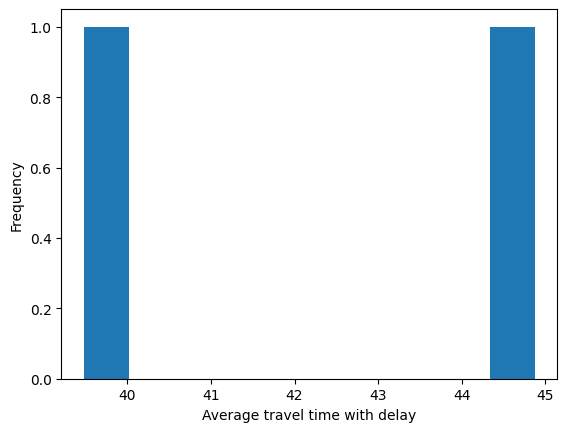

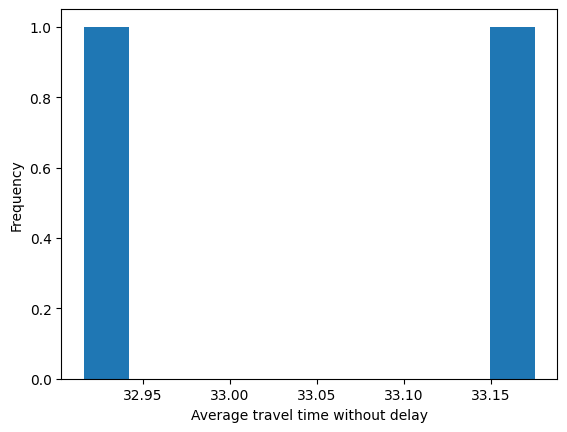

[0 0 0 ... 0 0 0]


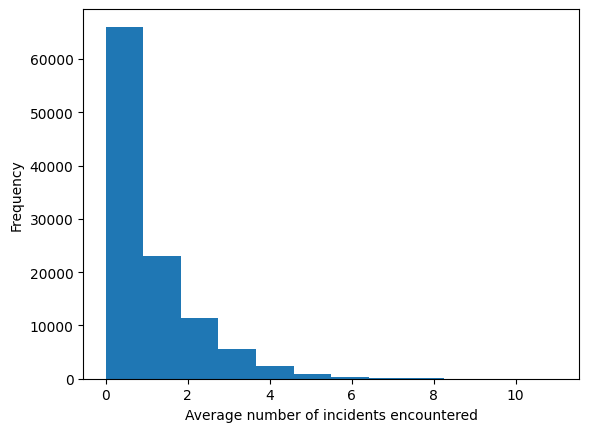

[[[42.176345454378406, 2.6990357110722094], [33.04560814412673, 0.12960971076835293], [0.7379124021495026, 0.03639214725646667]], array([3.74340220e-01, 2.52792320e-03, 9.63546647e-03, ...,
       2.85981506e-05, 9.63372401e-06, 3.90555147e-06]), array([3.10168784e-02, 1.02156855e-01, 2.46479776e-02, 1.62707777e-02,
       5.89237548e-03, 1.53221577e-02, 7.00195947e-03, 6.43890994e-03,
       5.00146360e-03, 3.07902555e-03, 4.71549952e-03, 2.73572007e-03,
       5.34432747e-03, 4.89290881e-03, 3.50591737e-03, 2.59548308e-03,
       3.25152335e-03, 5.10935500e-03, 8.74015606e-03, 1.95463841e-02,
       6.92074229e-02, 5.64352243e-02, 2.92220770e-02, 2.93801766e-02,
       2.30764443e-02, 1.45474895e-02, 1.60868539e-02, 1.08385887e-02,
       1.26852092e-02, 1.69449103e-02, 1.32557942e-02, 1.61215311e-02,
       1.19367810e-02, 9.24580992e-03, 9.78755147e-03, 2.64784913e-03,
       1.16886336e-03, 5.97517588e-04, 8.21555183e-04, 4.78632955e-02,
       1.98268174e-01, 1.68436048e-02, 6.95

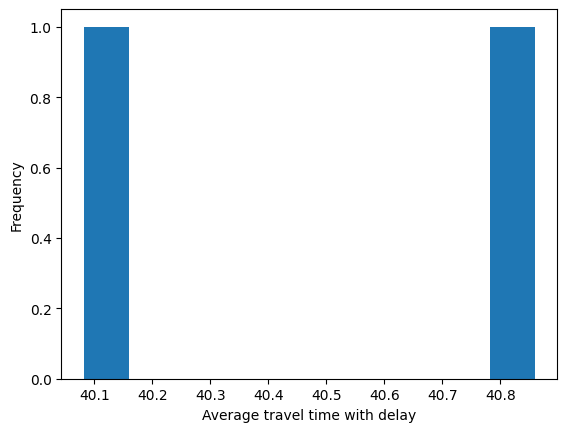

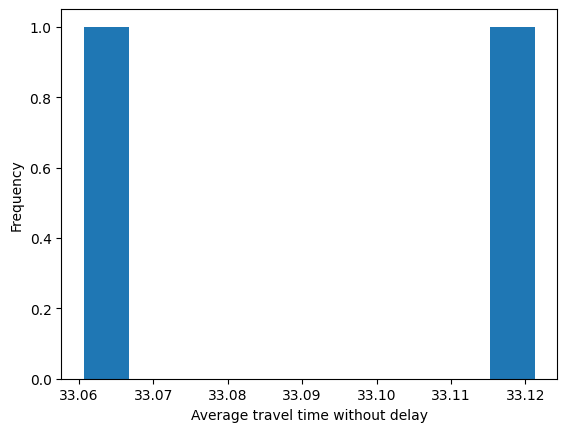

[0 0 0 ... 0 0 0]


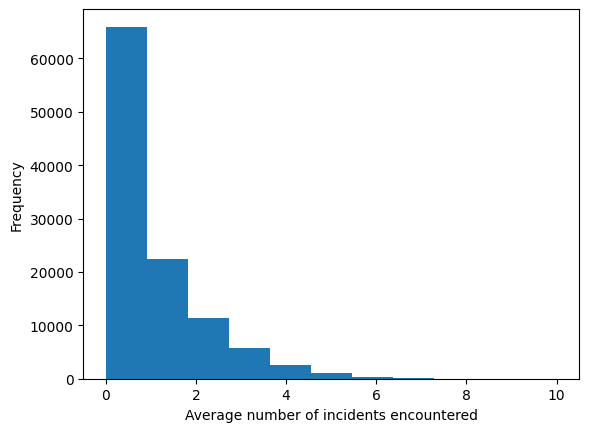

[[[40.47045812855717, 0.3886567961203618], [33.09095907051895, 0.030291524654501245], [0.7369057543130049, 0.014030199081081718]], array([4.40301479e-01, 3.87767121e-03, 1.27792699e-03, ...,
       9.68654302e-06, 1.41814226e-05, 1.73090599e-06]), array([5.00635883e-02, 1.71546253e-02, 1.17783790e-02, 7.11570757e-03,
       4.12725823e-03, 2.88352127e-05, 3.71391837e-04, 1.66544176e-03,
       5.50088079e-04, 1.13296736e-03, 2.86373027e-03, 4.78043622e-03,
       2.76282204e-03, 3.81888333e-03, 1.89864475e-03, 1.13333840e-03,
       8.64895574e-02, 1.46893710e-02, 4.98266737e-03, 3.01704195e-03,
       1.71927370e-03, 1.57611620e-03, 1.06467625e-03, 2.04932180e-03,
       2.35338969e-03, 3.03077400e-03, 3.20545918e-03, 1.42640432e-03,
       2.24226865e-03, 1.40655849e-03, 2.94370510e-04, 9.68108635e-04,
       2.96856135e-03, 1.61985102e-03, 2.14133383e-03, 1.23612437e-03,
       1.99343055e-03, 2.16557801e-03, 8.59283745e-04, 9.41302994e-04,
       2.68356023e-03, 4.05033271e-03, 2.4

In [ ]:
nruns = 2
k_values = [1, 5, 50, 100]
sims4 = [Simulation(nruns) for n in k_values]

for n, k in enumerate(k_values):
    print(f'{k} Tow trucks')
    sim = sims4[n]
    sim.compute_all_data4(k)
    if k == 5:
        sim.compute_table4()
    sim.performance_measures4()
    print(sim.pmeasures4)
    print('Problematic array pm2_cars_struck')
    print(sim.pmeasures4[1][5:])
    print(sim.pmeasures4[1][:-3])
    print(f'Max amount {len(sim.pmeasures4[1]) - 1}')
    print('-----------------------------------------------')
    #ADD CODE HERE TO SAVE OTHER FILE

In [19]:
np.cumsum(sims4[0].data4[0].LIST_AMOUNT_INCIDENTS_CHANGE)

array([  0,   0,   0, ..., 566, 566, 566])